In [3]:
library(Seurat)
spatial_data=readRDS("/home/shaliu_fu/multireg/cellGRN/data/spatial_brain/cortex_pseudotime_combined.rds")

In [4]:
spatial_data

An object of class Seurat 
223308 features across 675 samples within 2 assays 
Active assay: RNA (32285 features, 2000 variable features)
 2 layers present: counts, data
 1 other assay present: peaks
 2 dimensional reductions calculated: UMAP, Combined

In [7]:
target_genes <- c('Pax6','Eomes','Tbr1','Neurod1')

expr_matrix <- GetAssayData(
    object = spatial_data, 
    assay = "RNA",  # 对应Active assay
    slot = "data"
)[target_genes, ]  # 仅筛选目标基因的行

# 计算每个基因的表达均值
gene_mean_expr <- rowMeans(expr_matrix)

# 输出结果
cat("\n目标基因的表达均值：\n")
print(gene_mean_expr)

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”



目标基因的表达均值：
     Pax6     Eomes      Tbr1   Neurod1 
0.5046038 0.0954084 0.1228667 0.1435040 


In [3]:
head(spatial_data@meta.data)

,Sample,array_col,array_row,Pseudotime_Combined
,<chr>,<int>,<int>,<dbl>
E11_0-S1_GATCTTACCTTGCGCC-1,E11_0-S1,27,14,1.1532125
E11_0-S1_GATCTTACAGAACGTC-1,E11_0-S1,27,13,0.9884679
E11_0-S1_GATCTTACCCAGTTCC-1,E11_0-S1,27,6,2.9654036
E11_0-S1_GATCTTACACCGCCAA-1,E11_0-S1,27,5,5.6013180
E11_0-S1_AGAGCTATTAGAGTAA-1,E11_0-S1,32,10,3.2948929
E11_0-S1_TTGACTTCCAACCGCT-1,E11_0-S1,33,8,4.1186161


In [4]:
dim(spatial_data)

[1] 32285   675

In [6]:
unique(spatial_data$Sample)

[1] "E11_0-S1" "E13_5-S1" "E15_5-S1" "E18_5-S1"

In [13]:
unique(spatial_data@meta.data$Sample)

[1] "E11_0-S1" "E13_5-S1" "E15_5-S1" "E18_5-S1"

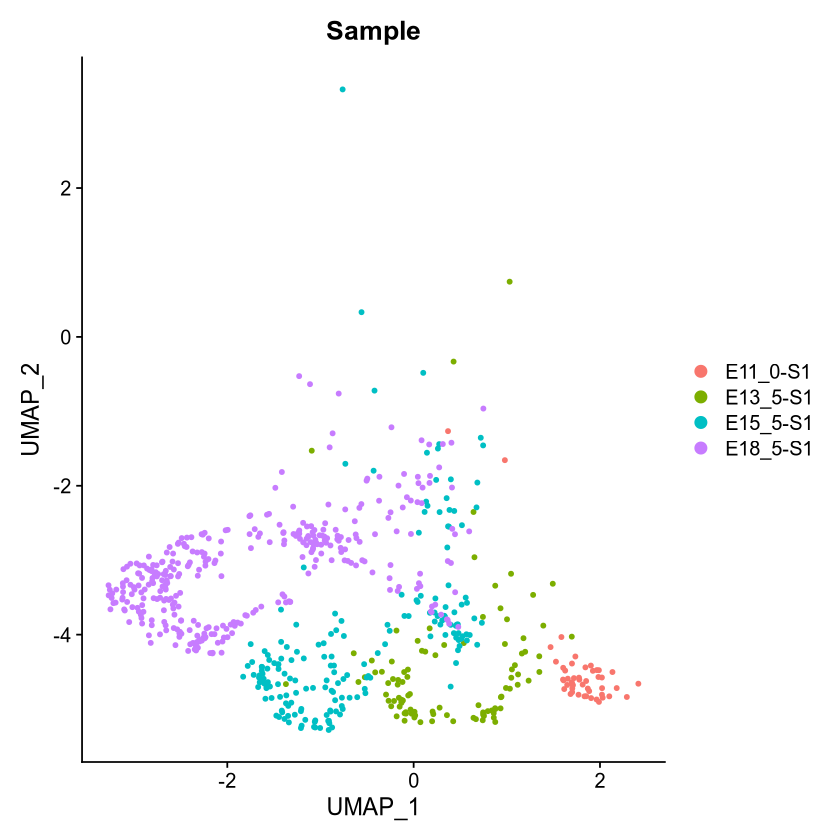

In [17]:
DimPlot(spatial_data, reduction = "UMAP", group.by = "Sample") 


In [5]:
dim(spatial_data[["RNA"]]$counts)



[1] 32285   675

In [25]:
spatial_data[["peaks"]]$counts[1:5, 1:5]


5 x 5 sparse Matrix of class "dgCMatrix"
                     E11_0-S1_GATCTTACCTTGCGCC-1 E11_0-S1_GATCTTACAGAACGTC-1
chr1-3094803-3095303                           .                           .
chr1-3113543-3114043                           .                           .
chr1-3120248-3120748                           .                           .
chr1-3325117-3325617                           .                           .
chr1-3399906-3400406                           .                           .
                     E11_0-S1_GATCTTACCCAGTTCC-1 E11_0-S1_GATCTTACACCGCCAA-1
chr1-3094803-3095303                           .                           .
chr1-3113543-3114043                           .                           .
chr1-3120248-3120748                           .                           .
chr1-3325117-3325617                           .                           .
chr1-3399906-3400406                           .                           .
                     E11_0-S1_AGAGC

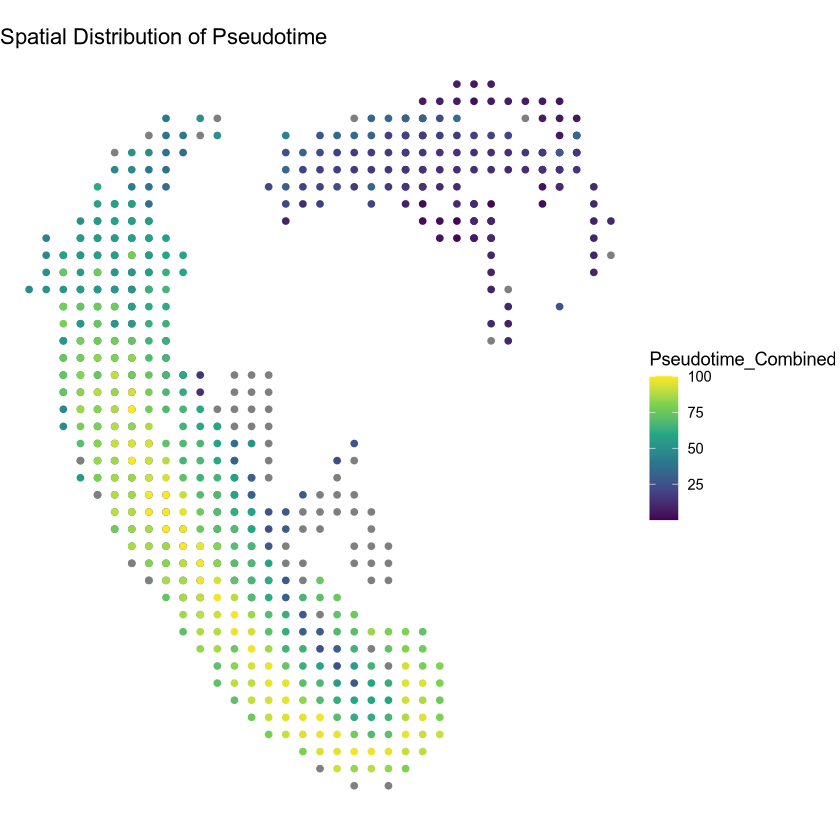

In [8]:
library(ggplot2)

# 假设你的对象名叫 spatial_data
# 我们用 array_col 和 array_row 作为坐标，用 Pseudotime_Combined 上色
ggplot(spatial_data@meta.data, aes(x = array_col, y = array_row, color = Pseudotime_Combined)) +
  geom_point(size = 1.5) +           # 点的大小
  scale_color_viridis_c() +          # 使用好看的渐变色
  theme_void() +                     # 去掉背景网格
  coord_fixed() +                    # 保证 X 和 Y 轴比例一致，防止图形拉伸
  scale_y_reverse() +                # 【关键】通常空间坐标的Y轴是反的（原点在左上角），如果图是倒的，加上这一行
  labs(title = "Spatial Distribution of Pseudotime")

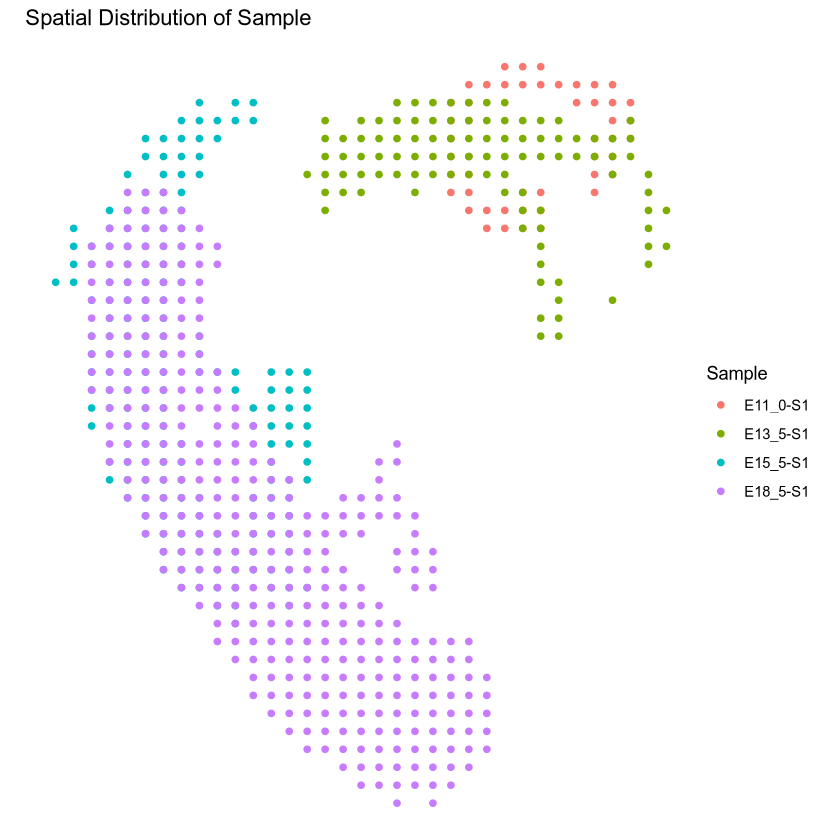

In [9]:
library(ggplot2)

# 假设你的对象名叫 spatial_data
# 我们用 array_col 和 array_row 作为坐标，用 Pseudotime_Combined 上色
ggplot(spatial_data@meta.data, aes(x = array_col, y = array_row, color = Sample)) +
  geom_point(size = 1.5) +           # 点的大小
  # scale_color_viridis_c() +          # 使用好看的渐变色
  theme_void() +                     # 去掉背景网格
  coord_fixed() +                    # 保证 X 和 Y 轴比例一致，防止图形拉伸
  scale_y_reverse() +                # 【关键】通常空间坐标的Y轴是反的（原点在左上角），如果图是倒的，加上这一行
  labs(title = "Spatial Distribution of Sample")

In [ ]:
# 输出表达矩阵和metadata，用于h5ad生成
rna_out = as.matrix(spatial_data[["RNA"]]$counts)
write.table(rna_out,file = "/home/shaliu_fu/multireg/cellGRN/data/spatial_brain/rna_count.csv",row.names=TRUE,col.names=TRUE,quote=FALSE,sep=",")

In [ ]:
write.table(rna_out,file = "/home/shaliu_fu/multireg/cellGRN/data/spatial_brain/rna_count.csv",row.names=TRUE,col.names=TRUE,quote=FALSE,sep=",")

In [ ]:
atac_out = as.matrix(spatial_data[["peaks"]]$counts)
write.table(atac_out,file = "/home/shaliu_fu/multireg/cellGRN/data/spatial_brain/atac_count.csv",row.names=TRUE,col.names=TRUE,quote=FALSE,sep=",")

In [22]:
write.table(atac_out,file = "/home/shaliu_fu/multireg/cellGRN/data/spatial_brain/atac_count.csv",row.names=TRUE,col.names=TRUE,quote=FALSE,sep=",")

In [20]:
out_meta = spatial_data@meta.data
out_meta['barcode'] = rownames(out_meta)

In [21]:
write.csv(out_meta,file="/home/shaliu_fu/multireg/cellGRN/data/spatial_brain/metadata.csv",row.names=FALSE,col.names=TRUE,quote=FALSE)

Warning message in write.csv(out_meta, file = "/home/shaliu_fu/multireg/cellGRN/data/spatial_brain/metadata.csv", :
“attempt to set 'col.names' ignored”
